In [1]:
import numpy as np
import pandas as pd
import os
from scipy.io import loadmat, savemat
from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load mean waveforms and cluster IDs from matlab
matlab_path = r"\\fsmresfiles.fsm.northwestern.edu\fsmresfiles\Basic_Sciences\Phys\SenzaiLab\Aparna\Mouse08\mean-waveforms-good-clusters"
mat_file = os.path.join(matlab_path, "meanWav_units.mat")

ksDir = r"D:\Kilosort\Mouse08_SC_20251007_810to2250\kilosort4"
chan_pos_file = os.path.join(ksDir, 'channel_positions.npy')

data = loadmat(mat_file)
meanWav = data['meanWav']          # nChannels x nSamples x nUnits
good_clusters = data['good_clusters'].squeeze()  # 1D array of cluster IDs

chan_pos = np.load(chan_pos_file)
xpos = chan_pos[:, 0]
ypos = chan_pos[:, 1]

nCh, nS, nUnits = meanWav.shape
num_channels_to_plot = 21  # number of channels around peak to include
spatialWindow = 300 # micrometers

sr = 30000  # Sampling rate in Hz (from your MATLAB script)
sbefore = 30  # Samples before trough (from your MATLAB script)
safter = 60   # Samples after trough (from your MATLAB script)



In [2]:
# function to extract multi-channel waveforms and spatial features per unit

def get_multichannel_waveform_features(unit_idx, meanWav, xpos, ypos, num_channels=21, spatial_window=300):
    """
    Extract waveform features including spatial spread.
    
    Key differences:
    - RGC axons: LARGE spatial spread, fast bi/triphasic + slow trough
    - SC neurons: SMALL spatial spread, biphasic somatic action potential
    """
    mean_wave = meanWav[:, :, unit_idx]
    
    # Find peak channel (max absolute amplitude)
    peak_ch = np.argmax(np.max(np.abs(mean_wave), axis=1))
    peak_waveform = mean_wave[peak_ch, :]
    
    peak_x = xpos[peak_ch]
    peak_y = ypos[peak_ch]
    
    # Get same-shank, same-parity channels
    sameshank = np.where(xpos == peak_x)[0]
    peak_parity = peak_ch % 2
    same_parity = sameshank[sameshank % 2 == peak_parity]
    
    # Get spatial neighbors
    y_distance = np.abs(ypos[same_parity] - peak_y)
    nearby_idx = np.where(y_distance <= spatial_window)[0]
    channels_to_use = same_parity[nearby_idx]
    
    # If too few, expand to nearest neighbors
    if len(channels_to_use) < num_channels:
        sorted_idx = np.argsort(y_distance)
        n_take = min(num_channels, len(same_parity))
        channels_to_use = same_parity[sorted_idx[:n_take]]
    
    # If too many, keep closest
    if len(channels_to_use) > num_channels:
        distances = np.abs(ypos[channels_to_use] - peak_y)
        sorted_idx = np.argsort(distances)
        channels_to_use = channels_to_use[sorted_idx[:num_channels]]
    
    # Get multi-channel waveforms sorted by depth
    depth_order = np.argsort(ypos[channels_to_use])[::-1]  # superficial to deep
    sorted_channels = channels_to_use[depth_order]
    multichan_waveforms = mean_wave[sorted_channels, :]
    
    return {
        'peak_waveform': peak_waveform,
        'peak_ch': peak_ch,
        'channels': sorted_channels,
        'multichan_waveforms': multichan_waveforms,
        'channel_depths': ypos[sorted_channels],
        'peak_depth': peak_y
    }


In [3]:
# function to get waveforms across all channels, not just the 21 channels

def get_multichannel_waveform_features_uncapped(unit_idx, meanWav, xpos, ypos, 
                                                amplitude_threshold=0.1):
    """
    Extract waveform features WITHOUT arbitrary channel limits.
    Use amplitude threshold instead of fixed channel count.
    """
    mean_wave = meanWav[:, :, unit_idx]
    
    # Find peak channel (max absolute amplitude)
    peak_ch = np.argmax(np.max(np.abs(mean_wave), axis=1))
    peak_waveform = mean_wave[peak_ch, :]
    peak_amp = np.max(np.abs(peak_waveform))
    
    peak_x = xpos[peak_ch]
    peak_y = ypos[peak_ch]
    
    # Get same-shank, same-parity channels
    sameshank = np.where(xpos == peak_x)[0]
    peak_parity = peak_ch % 2
    same_parity_sameshank = sameshank[sameshank % 2 == peak_parity]
    
    # Instead of fixed num_channels, use ALL channels above amplitude threshold
    max_amps = np.max(np.abs(mean_wave[same_parity_sameshank, :]), axis=1)
    significant_mask = max_amps > (amplitude_threshold * peak_amp)
    channels_to_use = same_parity_sameshank[significant_mask]
    
    # Get multi-channel waveforms sorted by depth
    depth_order = np.argsort(ypos[channels_to_use])[::-1]
    sorted_channels = channels_to_use[depth_order]
    multichan_waveforms = mean_wave[sorted_channels, :]
    
    return {
        'peak_waveform': peak_waveform,
        'peak_ch': peak_ch,
        'channels': sorted_channels,
        'multichan_waveforms': multichan_waveforms,
        'channel_depths': ypos[sorted_channels],
        'peak_depth': peak_y,
        'peak_amp': peak_amp
    }

In [4]:
# Extract multi-channel waveform features for all units
unit_data = []
for i in tqdm(range(nUnits), desc="Extracting multi-channel waveforms"):
    data = get_multichannel_waveform_features_uncapped(i, meanWav, xpos, ypos)
    unit_data.append(data)

Extracting multi-channel waveforms:   0%|          | 0/130 [00:00<?, ?it/s]

In [5]:
# ==============================================================================
# IMPROVED SPATIAL SPREAD - Multiple Thresholds
# ==============================================================================

def calculate_spatial_spread_improved(multichan_waveforms, channel_depths, peak_depth, peak_amp):
    """
    Calculate spatial spread with multiple amplitude thresholds.
    """
    features = {}
    
    max_amps_per_channel = np.max(np.abs(multichan_waveforms), axis=1)
    
    # Multiple thresholds to capture spread at different levels
    thresholds = {
        '10pct': 0.1,
        '20pct': 0.2,
        '30pct': 0.3,
        '50pct': 0.5
    }
    
    for name, thresh in thresholds.items():
        active = max_amps_per_channel > (thresh * peak_amp)
        features[f'n_active_channels_{name}'] = np.sum(active)
        
        if np.sum(active) > 1:
            active_depths = channel_depths[active]
            features[f'spatial_extent_{name}'] = np.max(active_depths) - np.min(active_depths)
        else:
            features[f'spatial_extent_{name}'] = 0
    
    # Weighted spatial spread (amplitude-weighted standard deviation)
    if len(max_amps_per_channel) > 1:
        weights = max_amps_per_channel / np.sum(max_amps_per_channel)
        weighted_center = np.sum(weights * channel_depths)
        weighted_variance = np.sum(weights * (channel_depths - weighted_center)**2)
        features['spatial_spread_weighted_std'] = np.sqrt(weighted_variance)
    else:
        features['spatial_spread_weighted_std'] = 0
    
    # Amplitude decay rate (simple linear regression in log space)
    peak_ch_idx = np.argmax(max_amps_per_channel)
    distances = np.abs(channel_depths - channel_depths[peak_ch_idx])
    
    # Only use channels with measurable amplitude
    valid_mask = max_amps_per_channel > (0.05 * peak_amp)
    if np.sum(valid_mask) > 3:
        valid_distances = distances[valid_mask]
        valid_amps = max_amps_per_channel[valid_mask]
        
        # Log-linear fit: log(amp) ~ -distance/decay_constant
        log_amps = np.log(valid_amps + 1e-10)
        from scipy.stats import linregress
        slope, intercept, r_value, _, _ = linregress(valid_distances, log_amps)
        
        # Decay length is -1/slope (more negative slope = faster decay = smaller spread)
        if slope < 0:
            features['decay_length'] = -1 / slope
        else:
            features['decay_length'] = 1000  # Very slow decay
        features['decay_r_squared'] = r_value**2
    else:
        features['decay_length'] = 0
        features['decay_r_squared'] = 0
    
    return features


In [7]:
# EXTRACT SPATIAL SPREAD FEATURES

def calculate_spatial_spread(multichan_waveforms, channel_depths, peak_depth): # NOT USING THIS ONE ANYMORE
    """
    Calculate spatial spread of the waveform.
    
    RGC axons: Large spatial spread (activity on many channels)
    SC neurons: Small spatial spread (localized to soma)
    """
    features = {}
    
    # 1. Amplitude-based spread: Find channels with significant activity
    # Define "significant" as >20% of peak channel amplitude
    peak_amp = np.max(np.abs(multichan_waveforms[len(multichan_waveforms)//2, :]))  # middle channel (likely peak)
    threshold = 0.2 * peak_amp
    
    max_amps_per_channel = np.max(np.abs(multichan_waveforms), axis=1)
    active_channels = max_amps_per_channel > threshold
    
    features['n_active_channels'] = np.sum(active_channels)
    
    # 2. Spatial extent in micrometers
    if np.sum(active_channels) > 1:
        active_depths = channel_depths[active_channels]
        spatial_extent = np.max(active_depths) - np.min(active_depths)
        features['spatial_extent_um'] = spatial_extent
    else:
        features['spatial_extent_um'] = 0
    
    # 3. Weighted spatial spread (amplitude-weighted)
    weights = max_amps_per_channel / np.sum(max_amps_per_channel)
    weighted_depth = np.sum(weights * channel_depths)
    weighted_variance = np.sum(weights * (channel_depths - weighted_depth)**2)
    features['spatial_spread_weighted'] = np.sqrt(weighted_variance)
    
    # 4. Half-max spatial spread
    half_max = 0.5 * peak_amp
    half_max_channels = max_amps_per_channel > half_max
    if np.sum(half_max_channels) > 1:
        half_max_depths = channel_depths[half_max_channels]
        features['half_max_spread_um'] = np.max(half_max_depths) - np.min(half_max_depths)
    else:
        features['half_max_spread_um'] = 0
    
    return features


# EXTRACT TEMPORAL FEATURES (Fast + Slow Components)


def extract_temporal_features(waveform, sr=30000, sbefore=30):
    """
    Extract temporal features distinguishing RGC fast bi/triphasic + slow trough
    from SC biphasic waveforms.
    """
    features = {}
    
    # Time vector in ms
    t_ms = (np.arange(len(waveform)) - sbefore) / sr * 1000
    
    # === PRIMARY TROUGH (main negative deflection) ===
    primary_trough_idx = np.argmin(waveform)
    primary_trough_amp = waveform[primary_trough_idx]
    primary_trough_time = t_ms[primary_trough_idx]
    
    features['primary_trough_amp'] = abs(primary_trough_amp)
    features['primary_trough_time'] = primary_trough_time
    
    # === DETECT SECONDARY SLOW TROUGH (characteristic of RGCs) ===
    # Look for a second trough after the primary peak
    primary_peak_idx = np.argmax(waveform[primary_trough_idx:]) + primary_trough_idx
    
    # Search for secondary trough after primary peak (in the later 1-2 ms)
    search_start = primary_peak_idx + int(0.3 * sr / 1000)  # start 0.3ms after peak
    search_end = min(len(waveform), primary_peak_idx + int(2.5 * sr / 1000))  # search up to 2.5ms
    
    if search_end > search_start:
        late_segment = waveform[search_start:search_end]
        secondary_trough_idx_rel = np.argmin(late_segment)
        secondary_trough_idx = search_start + secondary_trough_idx_rel
        secondary_trough_amp = waveform[secondary_trough_idx]
        
        # Only count as secondary trough if significantly negative
        if secondary_trough_amp < -0.15 * abs(primary_trough_amp):
            features['has_secondary_trough'] = 1
            features['secondary_trough_amp'] = abs(secondary_trough_amp)
            features['secondary_trough_time'] = t_ms[secondary_trough_idx]
            features['secondary_to_primary_ratio'] = abs(secondary_trough_amp) / abs(primary_trough_amp)
        else:
            features['has_secondary_trough'] = 0
            features['secondary_trough_amp'] = 0
            features['secondary_trough_time'] = np.nan
            features['secondary_to_primary_ratio'] = 0
    else:
        features['has_secondary_trough'] = 0
        features['secondary_trough_amp'] = 0
        features['secondary_trough_time'] = np.nan
        features['secondary_to_primary_ratio'] = 0
    
    # === FAST COMPONENT DETECTION (bi/triphasic) ===
    # Look at the first 1ms after spike onset for fast oscillations
    fast_window = waveform[sbefore:sbefore + int(1.0 * sr / 1000)]
    
    # Count zero crossings (indicator of bi/triphasic nature)
    zero_crossings = np.sum(np.diff(np.sign(fast_window)) != 0)
    features['fast_zero_crossings'] = zero_crossings
    
    # Detect peaks in fast component
    peaks, _ = find_peaks(np.abs(fast_window), distance=int(0.1 * sr / 1000))
    features['n_fast_peaks'] = len(peaks)
    
    # === DURATION FEATURES ===
    # Trough-to-peak time
    features['trough_to_peak_time'] = (primary_peak_idx - primary_trough_idx) / sr * 1000
    
    # Half-width
    half_amp = primary_trough_amp / 2
    crossings = np.where(np.diff(np.sign(waveform - half_amp)))[0]
    if len(crossings) >= 2:
        features['half_width'] = (crossings[-1] - crossings[0]) / sr * 1000
    else:
        features['half_width'] = np.nan
    
    # Total duration (10-90% recovery)
    recovery_90 = 0.1 * primary_trough_amp
    post_trough = waveform[primary_trough_idx:]
    recovery_idx = np.where(post_trough >= recovery_90)[0]
    if len(recovery_idx) > 0:
        features['duration_10_90'] = recovery_idx[0] / sr * 1000
    else:
        features['duration_10_90'] = np.nan
    
    # === REPOLARIZATION FEATURES ===
    if primary_peak_idx + 10 < len(waveform):
        repol_slope = (waveform[primary_peak_idx + 10] - waveform[primary_peak_idx]) / (10 / sr * 1000)
        features['repol_slope'] = repol_slope
    else:
        features['repol_slope'] = np.nan
    
    # Peak-to-trough ratio
    primary_peak_amp = waveform[primary_peak_idx]
    features['peak_trough_ratio'] = primary_peak_amp / abs(primary_trough_amp)
    
    return features



In [9]:
# ==============================================================================
# 4. COMBINE ALL FEATURES
# ==============================================================================

all_features = []

for i, unit in enumerate(tqdm(unit_data, desc="Extracting all features")):
    features = {}
    
    # Spatial features
    spatial_feats = calculate_spatial_spread_improved(
        unit['multichan_waveforms'],
        unit['channel_depths'],
        unit['peak_depth'], 
        unit['peak_amp']
    )
    features.update(spatial_feats)
    
    # Temporal features from peak channel
    temporal_feats = extract_temporal_features(unit['peak_waveform'], sr, sbefore)
    features.update(temporal_feats)
    
    # Add metadata
    features['unit_idx'] = i
    features['cluster_id'] = good_clusters[i]
    features['peak_channel'] = unit['peak_ch']
    features['peak_depth'] = unit['peak_depth']
    
    all_features.append(features)

# Convert to DataFrame
features_df = pd.DataFrame(all_features)

print("\n=== FEATURE SUMMARY ===")
# Updated column names to match the new spatial features
print(features_df[['n_active_channels_10pct', 'n_active_channels_30pct',
                   'spatial_extent_10pct', 'spatial_extent_30pct', 
                   'decay_length', 'has_secondary_trough', 
                   'secondary_to_primary_ratio', 'trough_to_peak_time']].describe())

# Also print all available columns to confirm what we have
print("\n=== AVAILABLE FEATURES ===")
print(features_df.columns.tolist())

Extracting all features:   0%|          | 0/130 [00:00<?, ?it/s]


=== FEATURE SUMMARY ===
       n_active_channels_10pct  n_active_channels_30pct  spatial_extent_10pct  \
count               130.000000               130.000000            130.000000   
mean                 10.184615                 5.538462            279.230774   
std                   4.589818                 2.696980            143.843231   
min                   2.000000                 1.000000             30.000000   
25%                   7.000000                 4.000000            180.000000   
50%                   9.000000                 5.000000            240.000000   
75%                  13.000000                 7.000000            360.000000   
max                  24.000000                23.000000            690.000000   

       spatial_extent_30pct  decay_length  has_secondary_trough  \
count            130.000000    130.000000            130.000000   
mean             137.307692    107.965186              0.153846   
std               83.432082    228.281972   

In [10]:

# ==============================================================================
# CLUSTERING BASED ON SPATIAL + TEMPORAL FEATURES USING 11 FEATURES
# ==============================================================================

# Select key discriminating features (UPDATED NAMES)
feature_cols = [
    'spatial_extent_10pct',        # KEY: RGCs have large spread (replaces spatial_extent_um)
    'spatial_extent_30pct',        # KEY: More stringent threshold
    'decay_length',                # KEY: RGCs have slower amplitude decay (NEW)
    'spatial_spread_weighted_std', # KEY: RGCs have large spread (replaces spatial_spread_weighted)
    'n_active_channels_10pct',     # KEY: RGCs activate more channels (replaces n_active_channels)
    'has_secondary_trough',        # KEY: RGCs have slow secondary trough
    'secondary_to_primary_ratio',  # KEY: RGCs have prominent secondary trough
    'trough_to_peak_time',
    'half_width',
    'fast_zero_crossings',         # KEY: RGCs have more complex fast components
    'n_fast_peaks'
]

X = features_df[feature_cols].fillna(features_df[feature_cols].median())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=min(len(feature_cols), 5))
X_pca = pca.fit_transform(X_scaled)

print("\n=== PCA EXPLAINED VARIANCE ===")
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"PC{i+1}: {var:.3f}")

print("\n=== PCA COMPONENT LOADINGS (Top 3 features per PC) ===")
# Show which features contribute most to each PC
feature_names = np.array(feature_cols)
for i in range(min(3, pca.n_components_)):
    loadings = pca.components_[i]
    top_features = np.argsort(np.abs(loadings))[-3:][::-1]
    print(f"\nPC{i+1}:")
    for idx in top_features:
        print(f"  {feature_names[idx]}: {loadings[idx]:.3f}")

# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# K-means clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_scaled)

features_df['cluster_label'] = labels

# ==============================================================================
# CLUSTER STATISTICS
# ==============================================================================

cluster_stats = features_df.groupby('cluster_label')[
    ['spatial_extent_10pct', 'spatial_extent_30pct', 'decay_length',
     'n_active_channels_10pct', 'secondary_to_primary_ratio', 
     'has_secondary_trough', 'trough_to_peak_time']
].mean()

print("\n=== CLUSTER STATISTICS ===")
print(cluster_stats)

# Assign cell types (RGC = larger spatial extent + decay length + secondary trough)
rgc_score = (
    cluster_stats['spatial_extent_10pct'] + 
    cluster_stats['decay_length'] * 0.5 +  # Weight decay length less (it's noisy)
    cluster_stats['n_active_channels_10pct'] * 20 +
    cluster_stats['secondary_to_primary_ratio'] * 200
)
rgc_cluster = rgc_score.idxmax()
sc_cluster = 1 - rgc_cluster

features_df['cell_type'] = features_df['cluster_label'].map({
    rgc_cluster: 'RGC',
    sc_cluster: 'SC'
})

print(f"\n=== CELL TYPE ASSIGNMENT ===")
print(f"RGC Cluster: {rgc_cluster}")
print(f"SC Cluster: {sc_cluster}")
print(f"\nCell type counts:")
print(features_df['cell_type'].value_counts())



=== PCA EXPLAINED VARIANCE ===
PC1: 0.428
PC2: 0.159
PC3: 0.151
PC4: 0.087
PC5: 0.072

=== PCA COMPONENT LOADINGS (Top 3 features per PC) ===

PC1:
  spatial_spread_weighted_std: 0.426
  n_active_channels_10pct: 0.421
  spatial_extent_10pct: 0.415

PC2:
  fast_zero_crossings: 0.497
  secondary_to_primary_ratio: 0.433
  has_secondary_trough: 0.393

PC3:
  half_width: 0.569
  trough_to_peak_time: 0.504
  n_fast_peaks: -0.389


c:\Users\urs2027\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



=== CLUSTER STATISTICS ===
               spatial_extent_10pct  spatial_extent_30pct  decay_length  \
cluster_label                                                             
0                        223.960403            111.386139     69.374609   
1                        471.724152            227.586207    242.366851   

               n_active_channels_10pct  secondary_to_primary_ratio  \
cluster_label                                                        
0                             8.405941                    0.005395   
1                            16.379310                    0.297153   

               has_secondary_trough  trough_to_peak_time  
cluster_label                                             
0                          0.019802             0.400330  
1                          0.620690             0.317241  

=== CELL TYPE ASSIGNMENT ===
RGC Cluster: 1
SC Cluster: 0

Cell type counts:
cell_type
SC     101
RGC     29
Name: count, dtype: int64


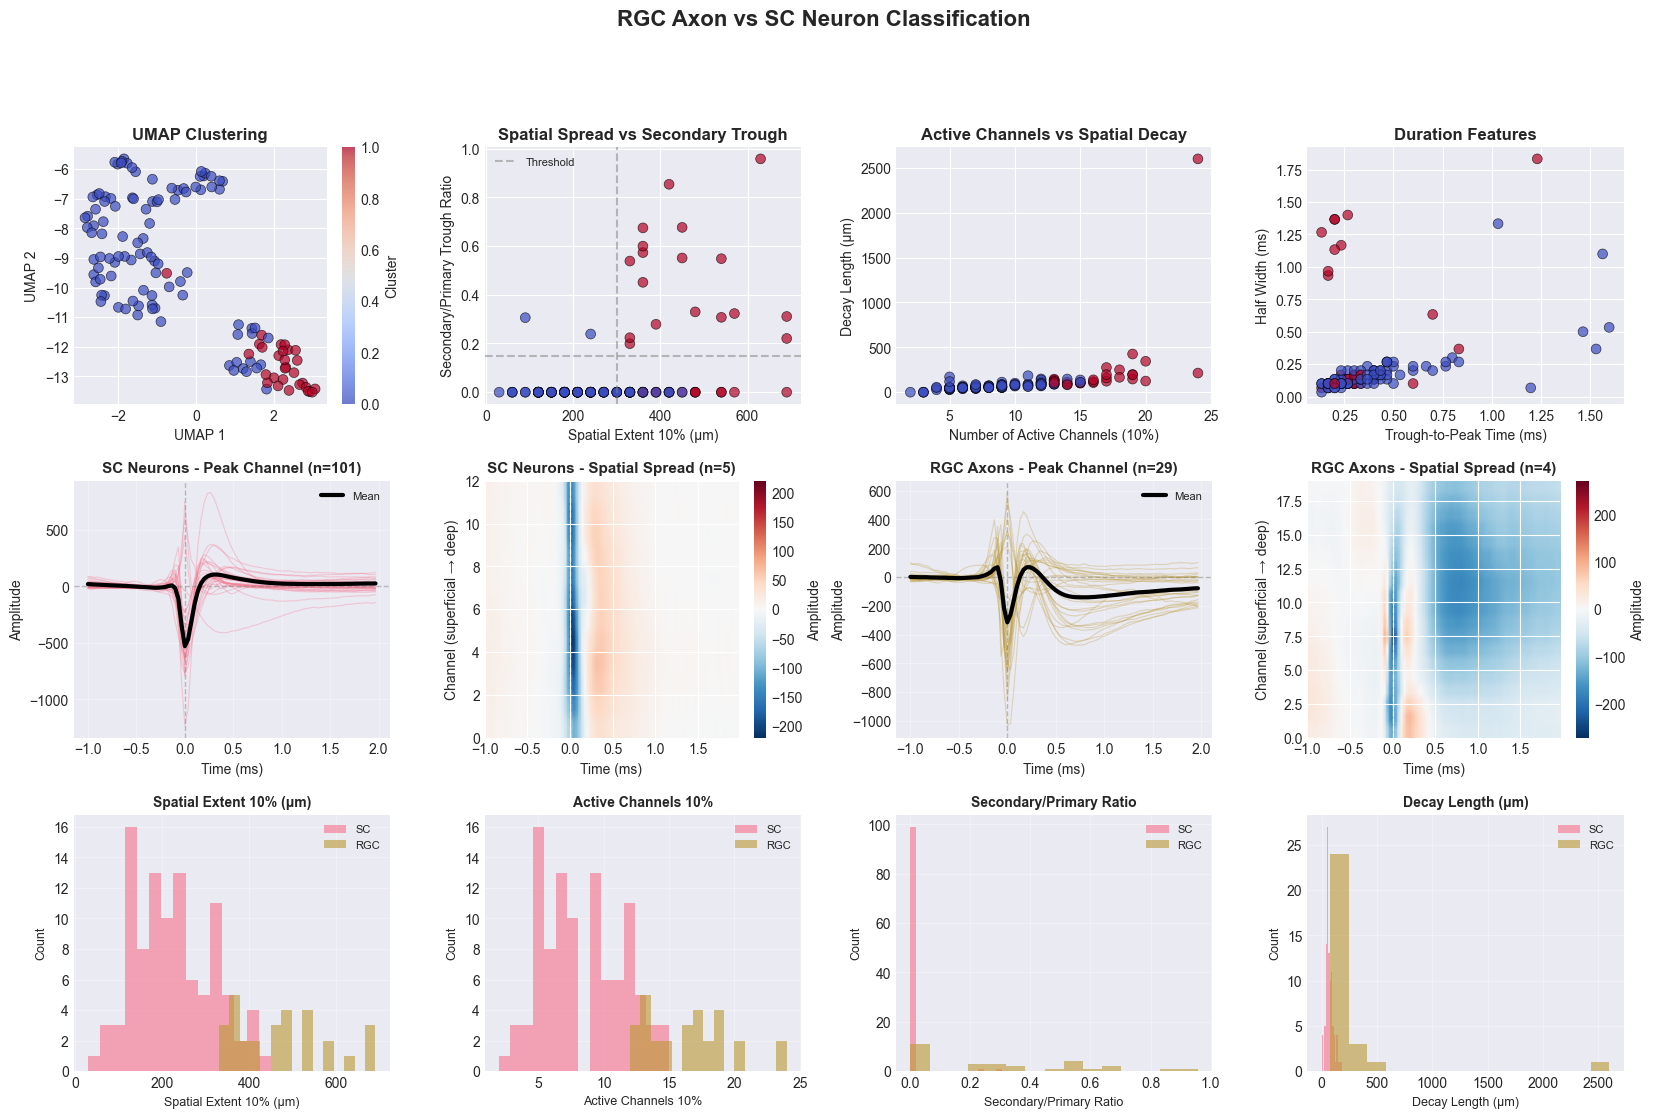


CELL TYPE CLASSIFICATION SUMMARY

           spatial_extent_10pct             spatial_extent_30pct          \
                          mean         std                 mean     std   
cell_type                                                                 
RGC                 471.720001  111.650002               227.59  111.25   
SC                  223.960007   96.800003               111.39   49.72   

          decay_length         n_active_channels_10pct        \
                  mean     std                    mean   std   
cell_type                                                      
RGC             242.37  460.33                   16.38  3.31   
SC               69.37   33.90                    8.41  3.13   

          secondary_to_primary_ratio       trough_to_peak_time        \
                                mean   std                mean   std   
cell_type                                                              
RGC                             0.30  0.29         

In [ ]:
# ==============================================================================
# 6. COMPREHENSIVE VISUALIZATION (UPDATED FOR IMPROVED FEATURES)
# ==============================================================================

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# --- Row 1: Clustering results ---
# UMAP
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax1.set_xlabel('UMAP 1', fontsize=10)
ax1.set_ylabel('UMAP 2', fontsize=10)
ax1.set_title('UMAP', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Cluster')

# Spatial extent vs secondary trough (KEY DISCRIMINATOR) - UPDATED
ax2 = fig.add_subplot(gs[0, 1])
scatter = ax2.scatter(features_df['spatial_extent_10pct'], features_df['secondary_to_primary_ratio'], 
                      c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax2.set_xlabel('Spatial Extent 10% (μm)', fontsize=10)
ax2.set_ylabel('Secondary/Primary Trough Ratio', fontsize=10)
ax2.set_title('Spatial Spread vs Secondary Trough', fontsize=12, fontweight='bold')
ax2.axhline(0.15, color='gray', linestyle='--', alpha=0.5, label='Threshold')
ax2.axvline(300, color='gray', linestyle='--', alpha=0.5)
ax2.legend(fontsize=8)

# Number of active channels vs decay length - UPDATED
ax3 = fig.add_subplot(gs[0, 2])
scatter = ax3.scatter(features_df['n_active_channels_10pct'], features_df['decay_length'], 
                      c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax3.set_xlabel('Number of Active Channels (10%)', fontsize=10)
ax3.set_ylabel('Decay Length (μm)', fontsize=10)
ax3.set_title('Active Channels vs Spatial Decay', fontsize=12, fontweight='bold')

# Duration features
ax4 = fig.add_subplot(gs[0, 3])
scatter = ax4.scatter(features_df['trough_to_peak_time'], features_df['half_width'], 
                      c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax4.set_xlabel('Trough-to-Peak Time (ms)', fontsize=10)
ax4.set_ylabel('Half Width (ms)', fontsize=10)
ax4.set_title('Duration Features', fontsize=12, fontweight='bold')

# --- Row 2: Example waveforms from each cluster ---
for cluster_id in [0, 1]:
    cluster_units = np.where(labels == cluster_id)[0]
    
    # Single-channel waveforms
    ax = fig.add_subplot(gs[1, cluster_id*2])
    t_ms = (np.arange(nS) - sbefore) / sr * 1000
    
    for unit_idx in cluster_units[:30]:  # Plot up to 30
        wf = unit_data[unit_idx]['peak_waveform']
        ax.plot(t_ms, wf, alpha=0.3, color=f'C{cluster_id}', linewidth=0.8)
    
    mean_wf = np.mean([unit_data[i]['peak_waveform'] for i in cluster_units], axis=0)
    ax.plot(t_ms, mean_wf, color='black', linewidth=3, label='Mean', zorder=100)
    
    ax.set_xlabel('Time (ms)', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    
    # Add cell type label - UPDATED
    cell_type = 'SC Neurons' if cluster_id == sc_cluster else 'RGC Axons'
    ax.set_title(f'{cell_type} - Peak Channel (n={len(cluster_units)})', fontsize=11, fontweight='bold')
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # Multi-channel heatmap (spatial spread visualization) - FIXED
    ax = fig.add_subplot(gs[1, cluster_id*2 + 1])
    
    # Find units with similar number of channels for averaging
    # Get the most common number of channels in this cluster
    n_chans_list = [unit_data[i]['multichan_waveforms'].shape[0] for i in cluster_units[:20]]
    from collections import Counter
    most_common_n_chans = Counter(n_chans_list).most_common(1)[0][0]
    
    # Only average units with this number of channels
    compatible_units = [i for i in cluster_units[:20] 
                       if unit_data[i]['multichan_waveforms'].shape[0] == most_common_n_chans]
    
    if len(compatible_units) > 0:
        mean_multichan = np.mean([unit_data[i]['multichan_waveforms'] for i in compatible_units], axis=0)
        
        im = ax.imshow(mean_multichan, aspect='auto', cmap='RdBu_r', 
                       extent=[t_ms[0], t_ms[-1], 0, mean_multichan.shape[0]],
                       vmin=-np.max(np.abs(mean_multichan)), vmax=np.max(np.abs(mean_multichan)))
        ax.set_xlabel('Time (ms)', fontsize=10)
        ax.set_ylabel('Channel (superficial → deep)', fontsize=10)
        ax.set_title(f'{cell_type} - Spatial Spread (n={len(compatible_units)})', fontsize=11, fontweight='bold')
        ax.axvline(0, color='white', linestyle='--', alpha=0.7, linewidth=1)
        plt.colorbar(im, ax=ax, label='Amplitude')
    else:
        # If no compatible units, just show a representative single unit
        example_unit = cluster_units[0]
        multichan = unit_data[example_unit]['multichan_waveforms']
        
        im = ax.imshow(multichan, aspect='auto', cmap='RdBu_r', 
                       extent=[t_ms[0], t_ms[-1], 0, multichan.shape[0]],
                       vmin=-np.max(np.abs(multichan)), vmax=np.max(np.abs(multichan)))
        ax.set_xlabel('Time (ms)', fontsize=10)
        ax.set_ylabel('Channel (superficial → deep)', fontsize=10)
        ax.set_title(f'{cell_type} - Spatial Spread (single unit)', fontsize=11, fontweight='bold')
        ax.axvline(0, color='white', linestyle='--', alpha=0.7, linewidth=1)
        plt.colorbar(im, ax=ax, label='Amplitude')

# --- Row 3: Feature distributions - UPDATED
feature_comparison = ['spatial_extent_10pct', 'n_active_channels_10pct', 
                      'secondary_to_primary_ratio', 'decay_length']

feature_labels = ['Spatial Extent 10% (μm)', 'Active Channels 10%', 
                  'Secondary/Primary Ratio', 'Decay Length (μm)']

for idx, (feat, label) in enumerate(zip(feature_comparison, feature_labels)):
    ax = fig.add_subplot(gs[2, idx])
    
    for cluster_id in [0, 1]:
        cluster_data = features_df[features_df['cluster_label'] == cluster_id][feat]
        cell_type = 'SC' if cluster_id == sc_cluster else 'RGC'
        color = 'C0' if cluster_id == sc_cluster else 'C1'
        ax.hist(cluster_data, alpha=0.6, label=f'{cell_type}', bins=15, color=color)
    
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('RGC Axon vs SC Neuron Classification', fontsize=16, fontweight='bold', y=0.995)
# plt.savefig('cell_type_classification_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# ADDITIONAL: Summary Statistics Table
# ==============================================================================

print("\n" + "="*80)
print("CELL TYPE CLASSIFICATION SUMMARY")
print("="*80)

summary_stats = features_df.groupby('cell_type')[
    ['spatial_extent_10pct', 'spatial_extent_30pct', 'decay_length',
     'n_active_channels_10pct', 'secondary_to_primary_ratio', 
     'trough_to_peak_time', 'half_width']
].agg(['mean', 'std'])

print("\n", summary_stats.round(2))

print("\n" + "="*80)
print(f"Total Units: {len(features_df)}")
print(f"RGC Axons: {np.sum(features_df['cell_type'] == 'RGC')} ({100*np.sum(features_df['cell_type'] == 'RGC')/len(features_df):.1f}%)")
print(f"SC Neurons: {np.sum(features_df['cell_type'] == 'SC')} ({100*np.sum(features_df['cell_type'] == 'SC')/len(features_df):.1f}%)")
print("="*80)




# # ==============================================================================
# # 6. COMPREHENSIVE VISUALIZATION
# # ==============================================================================

# fig = plt.figure(figsize=(20, 12))
# gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# # --- Row 1: Clustering results ---
# # UMAP
# ax1 = fig.add_subplot(gs[0, 0])
# scatter = ax1.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
# ax1.set_xlabel('UMAP 1', fontsize=10)
# ax1.set_ylabel('UMAP 2', fontsize=10)
# ax1.set_title('UMAP Clustering', fontsize=12, fontweight='bold')
# plt.colorbar(scatter, ax=ax1, label='Cluster')

# # Spatial extent vs secondary trough (KEY DISCRIMINATOR)
# ax2 = fig.add_subplot(gs[0, 1])
# scatter = ax2.scatter(features_df['spatial_extent_um'], features_df['secondary_to_primary_ratio'], 
#                       c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
# ax2.set_xlabel('Spatial Extent (μm)', fontsize=10)
# ax2.set_ylabel('Secondary/Primary Trough Ratio', fontsize=10)
# ax2.set_title('Spatial Spread vs Secondary Trough', fontsize=12, fontweight='bold')
# ax2.axhline(0.15, color='gray', linestyle='--', alpha=0.5, label='Threshold')
# ax2.axvline(150, color='gray', linestyle='--', alpha=0.5)
# ax2.legend(fontsize=8)

# # Number of active channels vs fast components
# ax3 = fig.add_subplot(gs[0, 2])
# scatter = ax3.scatter(features_df['n_active_channels'], features_df['fast_zero_crossings'], 
#                       c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
# ax3.set_xlabel('Number of Active Channels', fontsize=10)
# ax3.set_ylabel('Fast Zero Crossings', fontsize=10)
# ax3.set_title('Spatial vs Temporal Complexity', fontsize=12, fontweight='bold')

# # Duration features
# ax4 = fig.add_subplot(gs[0, 3])
# scatter = ax4.scatter(features_df['trough_to_peak_time'], features_df['half_width'], 
#                       c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
# ax4.set_xlabel('Trough-to-Peak Time (ms)', fontsize=10)
# ax4.set_ylabel('Half Width (ms)', fontsize=10)
# ax4.set_title('Duration Features', fontsize=12, fontweight='bold')

# # --- Row 2: Example waveforms from each cluster ---
# for cluster_id in [0, 1]:
#     cluster_units = np.where(labels == cluster_id)[0]
    
#     # Single-channel waveforms
#     ax = fig.add_subplot(gs[1, cluster_id*2])
#     t_ms = (np.arange(nS) - sbefore) / sr * 1000
    
#     for unit_idx in cluster_units[:30]:  # Plot up to 30
#         wf = unit_data[unit_idx]['peak_waveform']
#         ax.plot(t_ms, wf, alpha=0.3, color=f'C{cluster_id}', linewidth=0.8)
    
#     mean_wf = np.mean([unit_data[i]['peak_waveform'] for i in cluster_units], axis=0)
#     ax.plot(t_ms, mean_wf, color='black', linewidth=3, label='Mean', zorder=100)
    
#     ax.set_xlabel('Time (ms)', fontsize=10)
#     ax.set_ylabel('Amplitude', fontsize=10)
#     ax.set_title(f'Cluster {cluster_id} - Peak Channel (n={len(cluster_units)})', fontsize=11, fontweight='bold')
#     ax.axvline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
#     ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
#     ax.legend(fontsize=8)
#     ax.grid(alpha=0.3)
    
#     # Multi-channel heatmap (spatial spread visualization)
#     ax = fig.add_subplot(gs[1, cluster_id*2 + 1])
    
#     # Average across cluster
#     mean_multichan = np.mean([unit_data[i]['multichan_waveforms'] for i in cluster_units[:20]], axis=0)
    
#     im = ax.imshow(mean_multichan, aspect='auto', cmap='RdBu_r', 
#                    extent=[t_ms[0], t_ms[-1], 0, mean_multichan.shape[0]],
#                    vmin=-np.max(np.abs(mean_multichan)), vmax=np.max(np.abs(mean_multichan)))
#     ax.set_xlabel('Time (ms)', fontsize=10)
#     ax.set_ylabel('Channel (superficial → deep)', fontsize=10)
#     ax.set_title(f'Cluster {cluster_id} - Spatial Spread', fontsize=11, fontweight='bold')
#     ax.axvline(0, color='white', linestyle='--', alpha=0.7, linewidth=1)
#     plt.colorbar(im, ax=ax, label='Amplitude')

# # --- Row 3: Feature distributions ---
# feature_comparison = ['spatial_extent_um', 'n_active_channels', 
#                       'secondary_to_primary_ratio', 'trough_to_peak_time']

# for idx, feat in enumerate(feature_comparison):
#     ax = fig.add_subplot(gs[2, idx])
    
#     for cluster_id in [0, 1]:
#         cluster_data = features_df[features_df['cluster_label'] == cluster_id][feat]
#         ax.hist(cluster_data, alpha=0.6, label=f'Cluster {cluster_id}', bins=15, color=f'C{cluster_id}')
    
#     ax.set_xlabel(feat.replace('_', ' ').title(), fontsize=9)
#     ax.set_ylabel('Count', fontsize=9)
#     ax.set_title(f'{feat.replace("_", " ").title()}', fontsize=10, fontweight='bold')
#     ax.legend(fontsize=8)
#     ax.grid(alpha=0.3)

# plt.suptitle('RGC Axon vs SC Neuron Classification', fontsize=16, fontweight='bold', y=0.995)
# # plt.savefig('cell_type_classification_comprehensive.png', dpi=300, bbox_inches='tight')
# plt.show()

C:\Users\urs2027\AppData\Local\Temp\ipykernel_26460\2389382715.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=8)


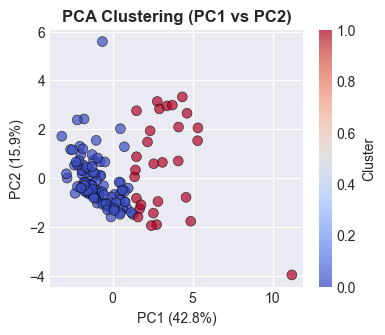

In [15]:
#### PCA Projection Visualization ####
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# PCA - PC1 vs PC2
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax1.set_title('PCA Clustering (PC1 vs PC2)', fontsize=12, fontweight='bold')

# Plot cluster centers
# centers_pca = pca.transform(kmeans.cluster_centers_)
# ax1.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=300, 
#            edgecolors='yellow', linewidths=3, label='Centroids', zorder=100)
ax1.legend(fontsize=8)
plt.colorbar(scatter, ax=ax1, label='Cluster')

Text(0.5, 1.0, 'PCA: PC1 vs PC3')

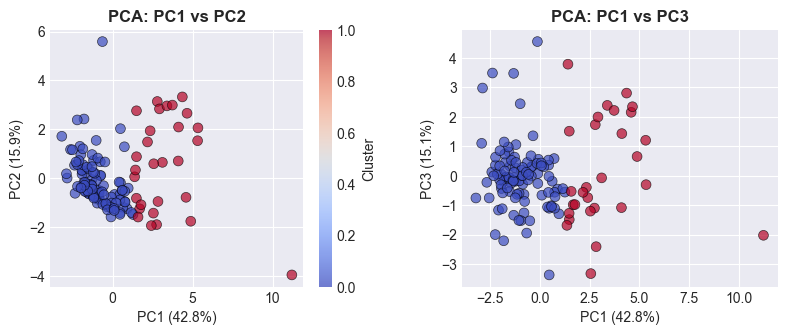

In [17]:
#### Multiple PCA Views

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
# --- Row 1: Multiple PCA views + feature spaces ---

# PC1 vs PC2
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax1.set_title('PCA: PC1 vs PC2', fontsize=12, fontweight='bold')
# centers_pca = pca.transform(kmeans.cluster_centers_)
# ax1.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=200, 
#            edgecolors='yellow', linewidths=2, zorder=100)
plt.colorbar(scatter, ax=ax1, label='Cluster')

# PC1 vs PC3
ax2 = fig.add_subplot(gs[0, 1])
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 2], c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax2.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})', fontsize=10)
ax2.set_title('PCA: PC1 vs PC3', fontsize=12, fontweight='bold')
# ax2.scatter(centers_pca[:, 0], centers_pca[:, 2], c='black', marker='X', s=200, 
#            edgecolors='yellow', linewidths=2, zorder=100)

# Keep your existing feature space plots for ax3 and ax4
# ... (spatial extent vs secondary trough, etc.)

In [20]:
# ==============================================================================
# CLUSTER STATISTICS AND CELL TYPE ASSIGNMENT
# ==============================================================================

# RGCs should have: larger spatial extent, slower decay, more active channels, more secondary trough
cluster_stats = features_df.groupby('cluster_label')[
    ['spatial_extent_10pct', 'spatial_extent_30pct', 'decay_length',
     'n_active_channels_10pct', 'secondary_to_primary_ratio', 'has_secondary_trough',
     'trough_to_peak_time', 'half_width']
].mean()

print("\n" + "="*80)
print("CLUSTER STATISTICS")
print("="*80)
print(cluster_stats.round(2))

# Identify RGC cluster (higher spatial extent + decay length + secondary trough)
rgc_score = (
    cluster_stats['spatial_extent_10pct'] +           # Weight: 1x (in μm)
    cluster_stats['spatial_extent_30pct'] * 0.5 +     # Weight: 0.5x (more stringent threshold)
    cluster_stats['decay_length'] * 0.5 +             # Weight: 0.5x (can be noisy)
    cluster_stats['n_active_channels_10pct'] * 20 +   # Weight: 20x (scale up from ~10)
    cluster_stats['secondary_to_primary_ratio'] * 200 # Weight: 200x (scale up from ~0.3)
)

print("\n" + "="*80)
print("RGC SCORE CALCULATION")
print("="*80)
print("RGC Score (higher = more RGC-like):")
print(rgc_score.round(2))

rgc_cluster = rgc_score.idxmax()
sc_cluster = 1 - rgc_cluster

features_df['cell_type'] = features_df['cluster_label'].map({
    rgc_cluster: 'RGC',
    sc_cluster: 'SC'
})

print("\n" + "="*80)
print("CELL TYPE ASSIGNMENT")
print("="*80)
print(f"RGC Cluster: {rgc_cluster}")
print(f"SC Cluster: {sc_cluster}")
print(f"\nCell type counts:")
print(features_df['cell_type'].value_counts())
print(f"\nPercentages:")
for cell_type in ['RGC', 'SC']:
    count = (features_df['cell_type'] == cell_type).sum()
    pct = 100 * count / len(features_df)
    print(f"  {cell_type}: {count} units ({pct:.1f}%)")

# ==============================================================================
# DETAILED COMPARISON TABLE
# ==============================================================================

print("\n" + "="*80)
print("DETAILED FEATURE COMPARISON: RGC vs SC")
print("="*80)

comparison_features = [
    'spatial_extent_10pct', 'spatial_extent_30pct', 'decay_length',
    'n_active_channels_10pct', 'n_active_channels_30pct',
    'secondary_to_primary_ratio', 'has_secondary_trough',
    'trough_to_peak_time', 'half_width', 'fast_zero_crossings'
]

comparison_table = features_df.groupby('cell_type')[comparison_features].agg(['mean', 'std'])
print(comparison_table.round(2))

# Calculate fold differences
print("\n" + "="*80)
print("FOLD DIFFERENCES (RGC / SC)")
print("="*80)
rgc_means = features_df[features_df['cell_type'] == 'RGC'][comparison_features].mean()
sc_means = features_df[features_df['cell_type'] == 'SC'][comparison_features].mean()
fold_diff = rgc_means / sc_means

for feat in comparison_features:
    print(f"{feat:35s}: {fold_diff[feat]:6.2f}x")

print("="*80)



CLUSTER STATISTICS
               spatial_extent_10pct  spatial_extent_30pct  decay_length  \
cluster_label                                                             
0                        223.960007                111.39         69.37   
1                        471.720001                227.59        242.37   

               n_active_channels_10pct  secondary_to_primary_ratio  \
cluster_label                                                        
0                                 8.41                        0.01   
1                                16.38                        0.30   

               has_secondary_trough  trough_to_peak_time  half_width  
cluster_label                                                         
0                              0.02                 0.40        0.17  
1                              0.62                 0.32        0.51  

RGC SCORE CALCULATION
RGC Score (higher = more RGC-like):
cluster_label
0     483.54
1    1093.72
dtype: float64


In [25]:
# ==============================================================================
# SAVE SIMPLE CLASSIFICATION RESULTS (cluster_id + cell_type only)
# ==============================================================================

# Create simple results dataframe
results_dict = pd.DataFrame({
    'cluster_id': features_df['cluster_id'].values,
    'cell_type': features_df['cell_type'].values
})

# Sort by cluster_id
sort_idx = np.argsort(results_dict['cluster_id'])
results_dict['cluster_id'] = results_dict['cluster_id'][sort_idx]
results_dict['cell_type'] = results_dict['cell_type'][sort_idx]

# Save to CSV
output_dir = r"\\fsmresfiles.fsm.northwestern.edu\fsmresfiles\Basic_Sciences\Phys\SenzaiLab\Aparna\Mouse08\SC-RGC-classification-with-kmeans-all-channels-BEST"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

mat_path = os.path.join(output_dir, 'RGC-SC-classification.mat')
savemat(mat_path, results_dict)

print(f"✓ Results saved to: {mat_path}")
print(f"\nTotal units classified: {len(results_dict['cluster_id'])}")
print(f"  RGC: {np.sum(results_dict['cell_type'] == 'RGC')}")
print(f"  SC:  {np.sum(results_dict['cell_type'] == 'SC')}")

# Display first 10
print("\nFirst 10 rows:")
for i in range(min(10, len(results_dict['cluster_id']))):
    print(f"  Cluster {results_dict['cluster_id'][i]}: {results_dict['cell_type'][i]}")

✓ Results saved to: \\fsmresfiles.fsm.northwestern.edu\fsmresfiles\Basic_Sciences\Phys\SenzaiLab\Aparna\Mouse08\SC-RGC-classification-with-kmeans-all-channels-BEST\RGC-SC-classification.mat

Total units classified: 130
  RGC: 29
  SC:  101

First 10 rows:
  Cluster 2: SC
  Cluster 3: SC
  Cluster 11: SC
  Cluster 12: RGC
  Cluster 13: SC
  Cluster 17: SC
  Cluster 18: RGC
  Cluster 23: RGC
  Cluster 24: SC
  Cluster 27: RGC
